In [1]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import CosineAnnealingLR
import numpy as np
import matplotlib.pyplot as plt

from ViTGSOM import AutoEncoder, ViTLossReconstruction, SomLoss
from help_functions import get_grid_coords, decay_exponential, calculate_QE_TE_Purity, plot_umap_som_weights, get_node_hits, plot_som_weights, plot_som_mnist, plot_som_pie_grid

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(), 
])


dataset = datasets.USPS(root="./data", train=True, download=False, transform=transform)

In [3]:
config = {
    'img_size': 16,
    'patch_size': 4,
    'num_of_channels': 1,
    'embed_dim': 16,
    'enc_depth': 4,
    'dec_depth': 2,
    'num_heads': 2,
    'mlp_dim': 64,
    'epochs_pretrain': 20,
    'epochs_som': 3000,
    'fine_tuning_epochs': 100,
    'lr': 0.0005,
    'grow_after_epochs': 10,
    'som_rows': 5,
    'som_cols': 5,
}

In [4]:
autoencoder = AutoEncoder(img_size=config['img_size'], 
                          patch_size=config['patch_size'], 
                          num_of_channels=config['num_of_channels'], 
                          embed_dim=config['embed_dim'], 
                          enc_depth=config['enc_depth'],                                      
                          dec_depth=config['dec_depth'], 
                          num_heads=config['num_heads'], 
                          mlp_dim=config['mlp_dim'],
                          som_rows=config['som_rows'],
                          som_cols=config['som_cols'])    

In [5]:
criterionViT = ViTLossReconstruction()
criterionSOM = SomLoss()

loader = torch.utils.data.DataLoader(dataset=dataset, batch_size=32, shuffle=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

autoencoder.to(device)
autoencoder.train()

AutoEncoder(
  (encoder): ViTEncoder(
    (patch_embed): PatchEmbedding(
      (proj): Conv2d(1, 16, kernel_size=(4, 4), stride=(4, 4))
    )
    (blocks): ModuleList(
      (0-3): 4 x Block(
        (attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=16, out_features=16, bias=True)
        )
        (ln1): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (dense_1): Linear(in_features=16, out_features=64, bias=True)
          (activation): GELU(approximate='none')
          (dense_2): Linear(in_features=64, out_features=16, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (ln2): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
      )
    )
    (ln1): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
  )
  (decoder): ViTDecoder(
    (blocks): ModuleList(
      (0-1): 2 x Block(
        (attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLine

## Phase 1: Pretrain ViT

In [7]:
autoencoder.som_weights.requires_grad = False
for param in autoencoder.encoder.parameters():
    param.requires_grad = True
for param in autoencoder.decoder.parameters():
    param.requires_grad = True
    
paramsViT = list(autoencoder.encoder.parameters()) + list(autoencoder.decoder.parameters())
optimizerViT = optim.AdamW(paramsViT, lr=config['lr'])
scheduler = CosineAnnealingLR(optimizerViT, T_max=config['epochs_pretrain'])

history = {'MSE': []}

for epoch in range(config['epochs_pretrain']):
    running_mse = 0.0
    
    for images, _ in loader:
        images = images.to(device)
        
        reconstructed, latent = autoencoder(images)
        som_weights = autoencoder.get_som_weights()
        
        l_nn = criterionViT(images, reconstructed)
        
        optimizerViT.zero_grad()
        l_nn.backward()
        optimizerViT.step()
        running_mse += l_nn.item()
        
    scheduler.step()
    history['MSE'].append(running_mse/len(loader))
        
    print(f"Epoch {epoch+1}/{config['epochs_pretrain']}: MSE Loss {running_mse/len(loader):.8f}")

Epoch 1/20: MSE Loss 0.06612986
Epoch 2/20: MSE Loss 0.01241707
Epoch 3/20: MSE Loss 0.00743132
Epoch 4/20: MSE Loss 0.00557320
Epoch 5/20: MSE Loss 0.00433847
Epoch 6/20: MSE Loss 0.00347873
Epoch 7/20: MSE Loss 0.00295045
Epoch 8/20: MSE Loss 0.00256815
Epoch 9/20: MSE Loss 0.00228634
Epoch 10/20: MSE Loss 0.00208753
Epoch 11/20: MSE Loss 0.00193242
Epoch 12/20: MSE Loss 0.00180718
Epoch 13/20: MSE Loss 0.00170567
Epoch 14/20: MSE Loss 0.00161560
Epoch 15/20: MSE Loss 0.00154297
Epoch 16/20: MSE Loss 0.00148502
Epoch 17/20: MSE Loss 0.00144224
Epoch 18/20: MSE Loss 0.00141559
Epoch 19/20: MSE Loss 0.00139621
Epoch 20/20: MSE Loss 0.00139230


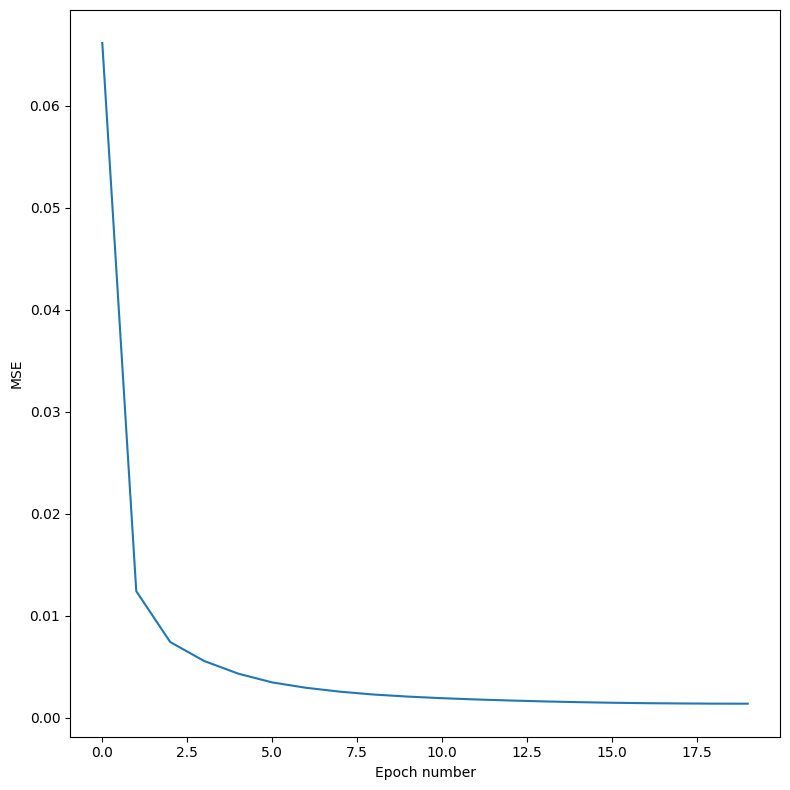

In [8]:
plt.figure(figsize=(8, 8))
plt.plot(np.arange(config['epochs_pretrain']), history['MSE'])
plt.ylabel('MSE')
plt.xlabel('Epoch number')
plt.tight_layout()
plt.show()

## Phase 2: GSOM training

In [9]:
torch.save(autoencoder, "/home/hanzlto3/ViT-GSOM/model_usps_early.pth")

In [13]:
autoencoder = torch.load("/home/hanzlto3/ViT-GSOM/model_usps_early.pth",weights_only=False)

In [14]:
autoencoder.som_weights.requires_grad = True
for param in autoencoder.encoder.parameters():
    param.requires_grad = False
for param in autoencoder.decoder.parameters():
    param.requires_grad = False

paramsSOM = autoencoder.som_weights
optimizerSOM = optim.AdamW([paramsSOM], lr=config['lr'])
scheduler = CosineAnnealingLR(optimizerSOM, T_max=config['epochs_som'])

sigma_start = autoencoder.get_sigma()
sigma_end = 0.3
beta = (sigma_end / sigma_start) ** (1 / config['grow_after_epochs'])
epochs_since_reset = 0

grid_coords = get_grid_coords(config['som_rows'], config['som_cols'], device)
current_sigma = sigma_start

history = {'som': [], 'purity': [], 'QE': [], 'TE': [], 'purity_end_cycle': [], "num_of_neurons": [], 'QE_end_cycle': [], 'TE_end_cycle': []}

best_som_weights = None
best_som_purity = None
best_som_shape = None

unique_labels = set()

print("Start GSOM training")
for epoch in range(config['epochs_som']):
    
    running_som = 0.0
    
    sigma_t = decay_exponential(sigma_start, beta, epochs_since_reset)

    for images, labels in loader:
        images = images.to(device)
        unique_labels.update(labels.tolist())
        
        reconstructed, latent = autoencoder(images)
        som_weights = autoencoder.get_som_weights()
        
        l_som = criterionSOM(latent, som_weights, grid_coords, sigma_t)
        
        optimizerSOM.zero_grad()
        l_som.backward()
        optimizerSOM.step()
        
        running_som += l_som.item()
    
    # updating learning rule through CosineAnnealingLR
    scheduler.step()

    metrics = calculate_QE_TE_Purity(autoencoder, loader, device)
    
    avg_som = running_som / len(loader)

    history['som'].append(avg_som)
    history['purity'].append(metrics["Purity"])
    history['QE'].append(metrics["QE"])
    history['TE'].append(metrics["TE"])
    
    print(f"Epoch {epoch+1}/{config['epochs_som']} | Sigma: {sigma_t:.3f} | SOM: {avg_som:.8f} | QE: {metrics["QE"]:.4f} | TE: {metrics["TE"]:.4f} | Purity: {metrics["Purity"]:.5f}")
        
    if epoch > 0 and (epoch + 1) % config['grow_after_epochs'] == 0:     
        history['purity_end_cycle'].append(metrics["Purity"])
        history['QE_end_cycle'].append(metrics["QE"])
        history['TE_end_cycle'].append(metrics["TE"])
        history['num_of_neurons'].append(autoencoder.get_num_of_neurons())
        
        if best_som_purity == None or metrics["Purity"] > best_som_purity:
            print(f"New best Purity found: {metrics["Purity"]}")
            best_som_purity = metrics["Purity"]
            best_som_weights = autoencoder.get_som_weights()
            best_som_shape = autoencoder.get_som_shape()
        
        epochs_since_reset += 1
        autoencoder.start_growth(loader, device)
        paramsSOM = autoencoder.get_som_weights()
        optimizerSOM = optim.AdamW([paramsSOM], lr=config['lr'])

        for param_group in optimizerSOM.param_groups: param_group['initial_lr'] = config['lr']

        scheduler = CosineAnnealingLR(optimizerSOM, T_max=config['epochs_som'], last_epoch=epoch)
        grid_coords = get_grid_coords(autoencoder.current_row_num, autoencoder.current_col_num, device)

        sigma_start = autoencoder.get_sigma()
        sigma_start = max(sigma_start, 2.0)
        beta = (sigma_end / sigma_start) ** (1 / max(1, config['grow_after_epochs']))
        epochs_since_reset = 0

    else:
        epochs_since_reset += 1   

print()
print("#########################################")
print(f"Best SOM purity: {best_som_purity:.5f} for shape: {best_som_shape}")
print("#########################################")


Start GSOM training
Epoch 1/3000 | Sigma: 3.000 | SOM: 16.28103692 | QE: 0.8037 | TE: 0.8888 | Purity: 0.25607
Epoch 2/3000 | Sigma: 2.383 | SOM: 12.19154532 | QE: 0.7233 | TE: 0.7417 | Purity: 0.21890
Epoch 3/3000 | Sigma: 1.893 | SOM: 8.38810208 | QE: 0.6414 | TE: 0.2913 | Purity: 0.21821
Epoch 4/3000 | Sigma: 1.504 | SOM: 5.48228564 | QE: 0.5615 | TE: 0.0166 | Purity: 0.19997
Epoch 5/3000 | Sigma: 1.194 | SOM: 3.51959586 | QE: 0.4898 | TE: 0.0001 | Purity: 0.17652
Epoch 6/3000 | Sigma: 0.949 | SOM: 2.20536819 | QE: 0.4247 | TE: 0.0000 | Purity: 0.16376
Epoch 7/3000 | Sigma: 0.754 | SOM: 1.34879444 | QE: 0.3658 | TE: 0.0000 | Purity: 0.16376
Epoch 8/3000 | Sigma: 0.599 | SOM: 0.80294783 | QE: 0.3145 | TE: 0.0000 | Purity: 0.16376
Epoch 9/3000 | Sigma: 0.475 | SOM: 0.47085780 | QE: 0.2702 | TE: 0.0000 | Purity: 0.16376
Epoch 10/3000 | Sigma: 0.378 | SOM: 0.29645217 | QE: 0.2322 | TE: 0.0000 | Purity: 0.16376
New best Purity found: 0.16376354409546015
Current grid size: (5, 6)
Epoch 11

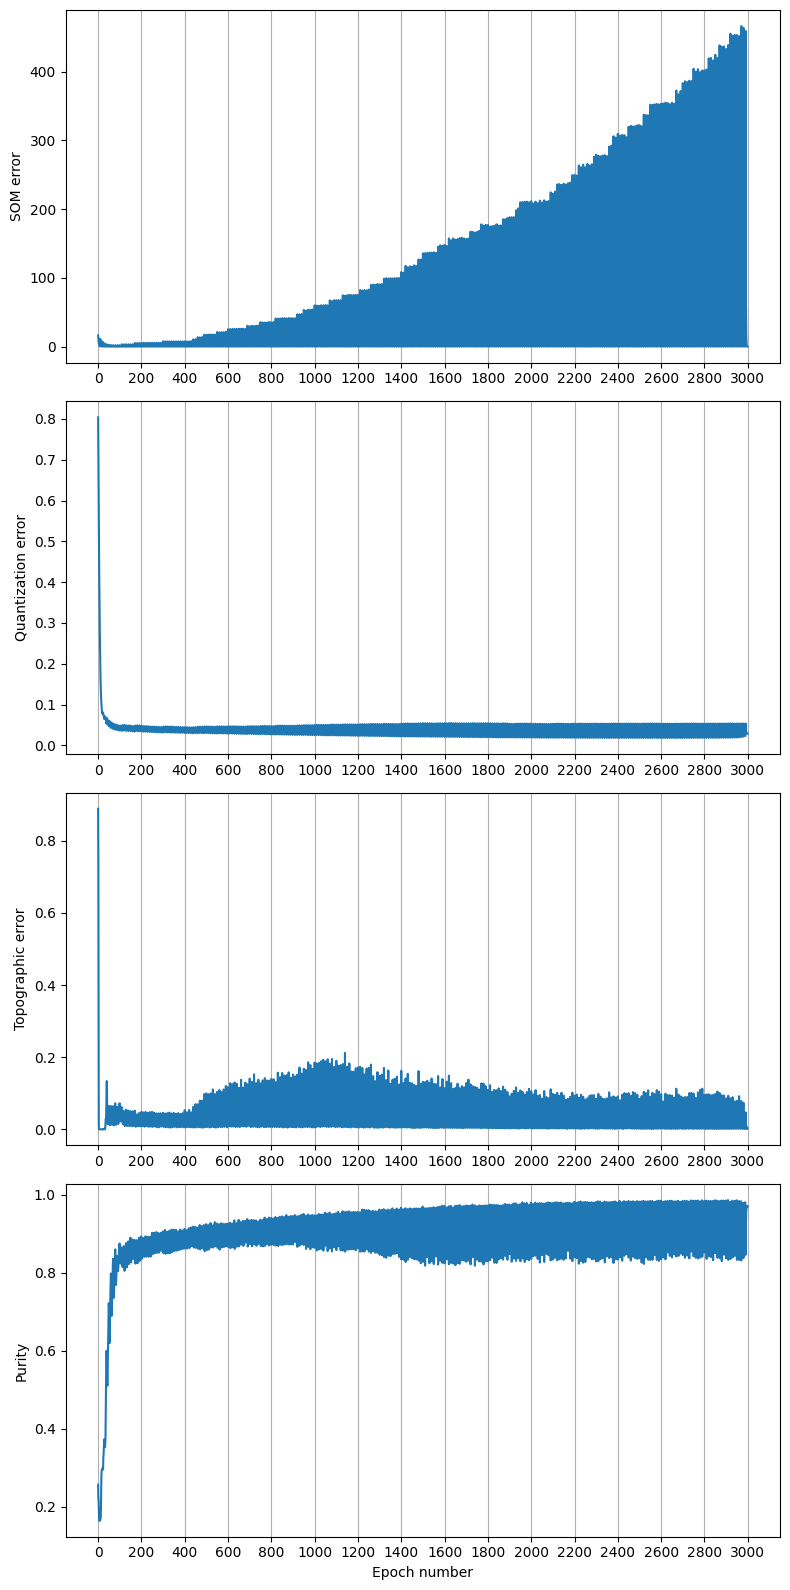

In [15]:
epochs_completed = len(history['QE'])
x = np.arange(epochs_completed)
xticks = np.arange(0, epochs_completed + 1, 200)

plt.figure(figsize=(8, 16))

plt.subplot(4,1,1)
plt.plot(x, history['som'])
plt.xticks(xticks)
plt.grid(axis='x')
plt.ylabel('SOM error')

plt.subplot(4,1,2)
plt.plot(x, history['QE'])
plt.xticks(xticks)
plt.grid(axis='x')
plt.ylabel('Quantization error')

plt.subplot(4,1,3)
plt.plot(x, history['TE'])
plt.xticks(xticks)
plt.grid(axis='x')
plt.ylabel('Topographic error')

plt.subplot(4,1,4)
plt.plot(x, history['purity'])
plt.xticks(xticks)
plt.grid(axis='x')
plt.ylabel('Purity')

plt.xlabel('Epoch number')
plt.tight_layout()
plt.show()

In [19]:
phase2_history = dict(history)

In [52]:
import pickle
with open('history_infinite.pkl', 'wb') as f:
    pickle.dump(phase2_history, f, pickle.HIGHEST_PROTOCOL)

In [54]:
with open('history_infinite.pkl', 'rb') as f:
    map_dict = pickle.load(f)

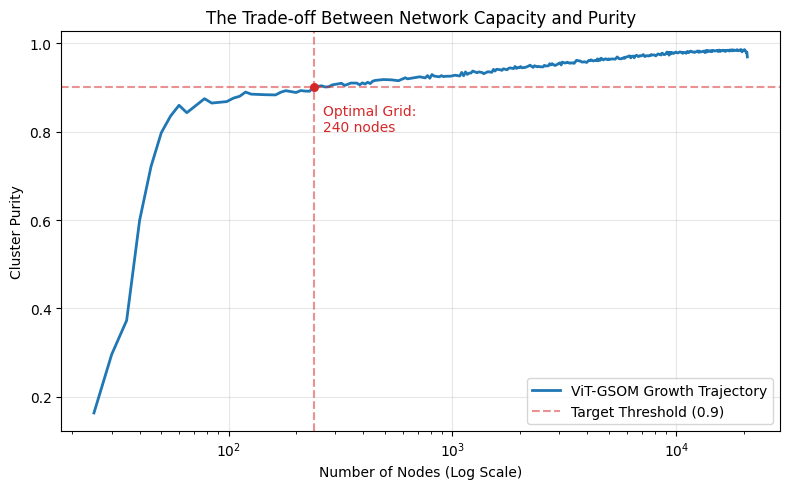

In [67]:
target_purity = 0.90

nodes = np.array(phase2_history['num_of_neurons'])
purities = np.array(phase2_history['purity_end_cycle'])

plt.figure(figsize=(8, 5))
plt.plot(nodes, purities, color='tab:blue', linewidth=2, label='ViT-GSOM Growth Trajectory')
plt.xscale('log')

stop_idx = np.argmax(purities >= target_purity)
stop_nodes = nodes[stop_idx]
stop_purity = purities[stop_idx]

plt.axhline(y=stop_purity, color='tab:red', linestyle='--', alpha=0.5, 
            label=f'Target Threshold ({target_purity})')
plt.axvline(x=stop_nodes, color='tab:red', linestyle='--', alpha=0.5)

plt.scatter([stop_nodes], [stop_purity], color='tab:red', s=30, zorder=5)

plt.text(stop_nodes * 1.1, stop_purity - 0.1, f'Optimal Grid:\n{stop_nodes} nodes', color='tab:red', fontsize=10)

plt.grid(True, which="major", linestyle="-", alpha=0.3)

plt.ylabel('Cluster Purity')
plt.xlabel('Number of Nodes (Log Scale)')
plt.title('The Trade-off Between Network Capacity and Purity')
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

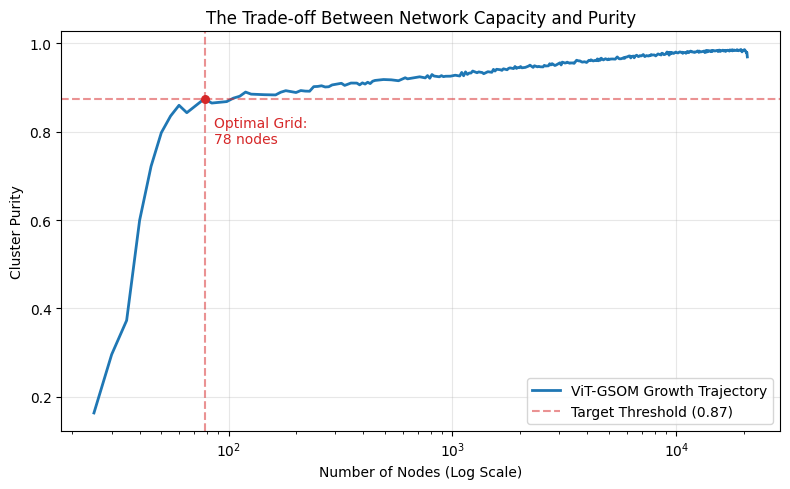

In [68]:
target_purity = 0.87

nodes = np.array(phase2_history['num_of_neurons'])
purities = np.array(phase2_history['purity_end_cycle'])

plt.figure(figsize=(8, 5))
plt.plot(nodes, purities, color='tab:blue', linewidth=2, label='ViT-GSOM Growth Trajectory')
plt.xscale('log')

stop_idx = np.argmax(purities >= target_purity)
stop_nodes = nodes[stop_idx]
stop_purity = purities[stop_idx]

plt.axhline(y=stop_purity, color='tab:red', linestyle='--', alpha=0.5, 
            label=f'Target Threshold ({target_purity})')
plt.axvline(x=stop_nodes, color='tab:red', linestyle='--', alpha=0.5)

plt.scatter([stop_nodes], [stop_purity], color='tab:red', s=30, zorder=5)

plt.text(stop_nodes * 1.1, stop_purity - 0.1, f'Optimal Grid:\n{stop_nodes} nodes', color='tab:red', fontsize=10)

plt.grid(True, which="major", linestyle="-", alpha=0.3)

plt.ylabel('Cluster Purity')
plt.xlabel('Number of Nodes (Log Scale)')
plt.title('The Trade-off Between Network Capacity and Purity')
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

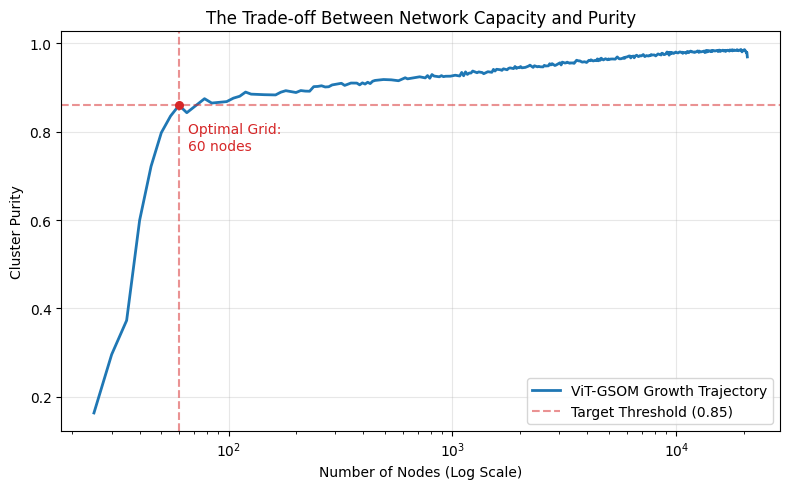

In [69]:
target_purity = 0.85

nodes = np.array(phase2_history['num_of_neurons'])
purities = np.array(phase2_history['purity_end_cycle'])

plt.figure(figsize=(8, 5))
plt.plot(nodes, purities, color='tab:blue', linewidth=2, label='ViT-GSOM Growth Trajectory')
plt.xscale('log')

stop_idx = np.argmax(purities >= target_purity)
stop_nodes = nodes[stop_idx]
stop_purity = purities[stop_idx]

plt.axhline(y=stop_purity, color='tab:red', linestyle='--', alpha=0.5, 
            label=f'Target Threshold ({target_purity})')
plt.axvline(x=stop_nodes, color='tab:red', linestyle='--', alpha=0.5)

plt.scatter([stop_nodes], [stop_purity], color='tab:red', s=30, zorder=5)

plt.text(stop_nodes * 1.1, stop_purity - 0.1, f'Optimal Grid:\n{stop_nodes} nodes', color='tab:red', fontsize=10)

plt.grid(True, which="major", linestyle="-", alpha=0.3)

plt.ylabel('Cluster Purity')
plt.xlabel('Number of Nodes (Log Scale)')
plt.title('The Trade-off Between Network Capacity and Purity')
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

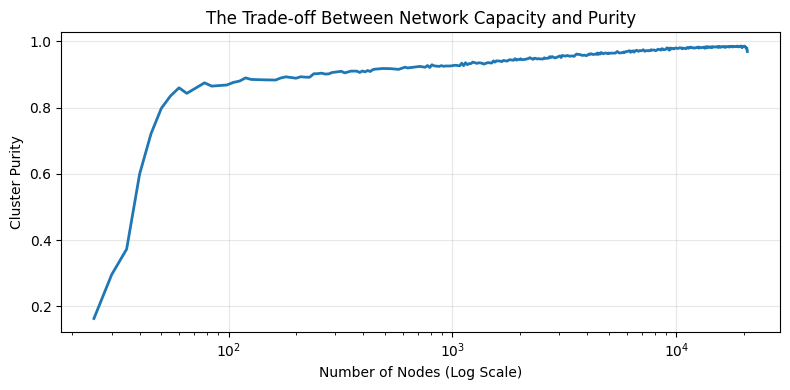

In [71]:
plt.figure(figsize=(8, 4))
plt.plot(phase2_history['num_of_neurons'], phase2_history['purity_end_cycle'], color='tab:blue', linewidth=2)
plt.xscale('log')
plt.grid(True, which="major", linestyle="-", alpha=0.3)

plt.ylabel('Cluster Purity')
plt.xlabel('Number of Nodes (Log Scale)')
plt.title('The Trade-off Between Network Capacity and Purity')

plt.tight_layout()
plt.show()

## Phase 3: ViT-GSOM Fine-Tuning

In [21]:
autoencoder.som_weights = best_som_weights
autoencoder.current_row_num, autoencoder.current_col_num = best_som_shape

In [22]:
autoencoder.get_som_shape()

(95, 205)

In [23]:
torch.save(autoencoder, "/home/hanzlto3/ViT-GSOM/model_usps_infinite.pth")

In [17]:
autoencoder = torch.load("D:/Tom/ViT-GHSOM/model.pth",weights_only=False)

In [24]:
final_rows, final_cols = autoencoder.get_som_shape()

autoencoder.som_weights.requires_grad = True
for param in autoencoder.encoder.parameters():
    param.requires_grad = False
for param in autoencoder.decoder.parameters():
    param.requires_grad = False

paramsSOM = autoencoder.get_som_weights()
optimizerSOM = optim.AdamW([paramsSOM], lr=config['lr'])
scheduler = CosineAnnealingLR(optimizerSOM, T_max=config['fine_tuning_epochs'], last_epoch=-1)

sigma_start = 2
sigma_end = 0.01
beta = (sigma_end / sigma_start) ** (1 / config['fine_tuning_epochs'])

grid_coords = get_grid_coords(autoencoder.current_row_num, autoencoder.current_col_num, device)
current_sigma = sigma_start

checkpoints = [i for i in range(0, config['fine_tuning_epochs'] + 1, 10)]
snapshot_som_weights_finetuning = {}
snapshot_som_weights_finetuning[0] = (
    autoencoder.get_som_weights().detach().cpu().numpy(),
    get_node_hits(autoencoder, loader, device)
)

history = {'som': [], 'purity': [], 'QE': [], 'TE': []}

print("Start training")
for epoch in range(config['fine_tuning_epochs']):
    
    running_som = 0.0
    
    sigma_t = decay_exponential(sigma_start, beta, epoch)
    last_sigma = sigma_t
    
    for images, _ in loader:
        images = images.to(device)
        
        reconstructed, latent = autoencoder(images)
        som_weights = autoencoder.get_som_weights()
        
        l_som = criterionSOM(latent, som_weights, grid_coords, sigma_t)
        
        optimizerSOM.zero_grad()
        l_som.backward()
        optimizerSOM.step()
        
        running_som += l_som.item()
    
    # updating learning rule through CosineAnnealingLR
    scheduler.step()

    metrics = calculate_QE_TE_Purity(autoencoder, loader, device)
    
    avg_som = running_som / len(loader)

    history['som'].append(avg_som)
    history['purity'].append(metrics["Purity"])
    history['QE'].append(metrics["QE"])
    history['TE'].append(metrics["TE"])
    
    print(f"Epoch {epoch+1}/{config['fine_tuning_epochs']} | Sigma: {sigma_t:.3f} | SOM: {avg_som:.8f} | QE: {metrics["QE"]:.4f} | TE: {metrics["TE"]:.4f} | Purity: {metrics["Purity"]:.5f}")

    if epoch+1 in checkpoints:        
        weights_np = autoencoder.get_som_weights().detach().cpu().numpy()
        labels_np = get_node_hits(autoencoder, loader, device)
        snapshot_som_weights_finetuning[epoch] = (weights_np, labels_np)

Start training
Epoch 1/100 | Sigma: 2.000 | SOM: 0.55682981 | QE: 0.0164 | TE: 0.0123 | Purity: 0.99054
Epoch 2/100 | Sigma: 1.897 | SOM: 0.47185202 | QE: 0.0142 | TE: 0.0093 | Purity: 0.99246
Epoch 3/100 | Sigma: 1.799 | SOM: 0.41068392 | QE: 0.0130 | TE: 0.0106 | Purity: 0.99451
Epoch 4/100 | Sigma: 1.706 | SOM: 0.35992508 | QE: 0.0120 | TE: 0.0085 | Purity: 0.99451
Epoch 5/100 | Sigma: 1.618 | SOM: 0.31445496 | QE: 0.0112 | TE: 0.0056 | Purity: 0.99575
Epoch 6/100 | Sigma: 1.535 | SOM: 0.27541256 | QE: 0.0105 | TE: 0.0058 | Purity: 0.99616
Epoch 7/100 | Sigma: 1.455 | SOM: 0.24059870 | QE: 0.0099 | TE: 0.0060 | Purity: 0.99671
Epoch 8/100 | Sigma: 1.380 | SOM: 0.20998974 | QE: 0.0093 | TE: 0.0071 | Purity: 0.99671
Epoch 9/100 | Sigma: 1.309 | SOM: 0.18300019 | QE: 0.0086 | TE: 0.0056 | Purity: 0.99685
Epoch 10/100 | Sigma: 1.241 | SOM: 0.15913040 | QE: 0.0080 | TE: 0.0062 | Purity: 0.99698
Epoch 11/100 | Sigma: 1.177 | SOM: 0.13801018 | QE: 0.0074 | TE: 0.0062 | Purity: 0.99712
Epoc

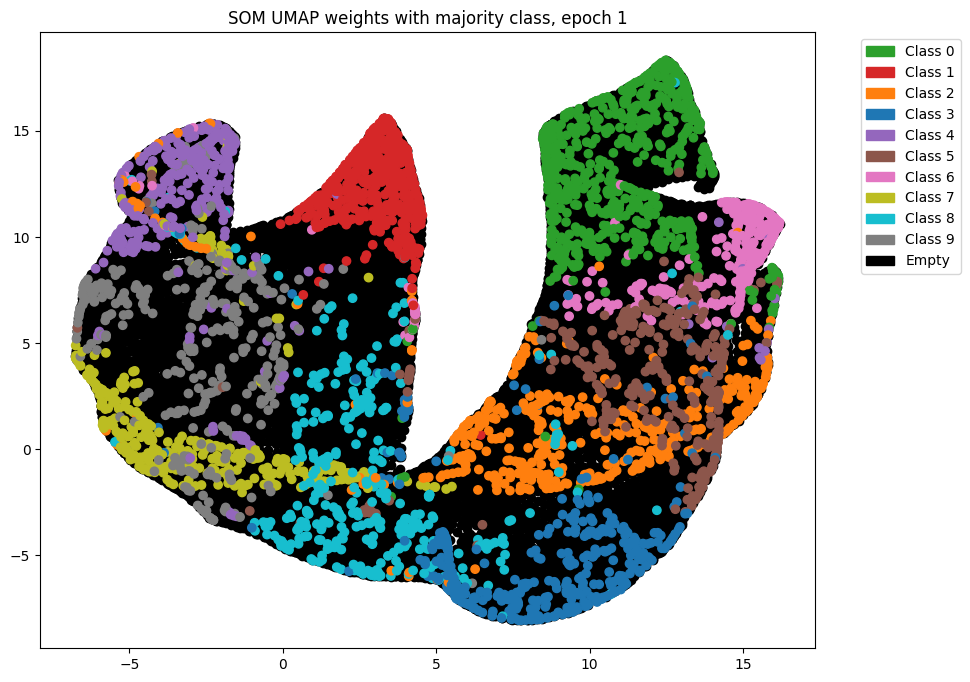

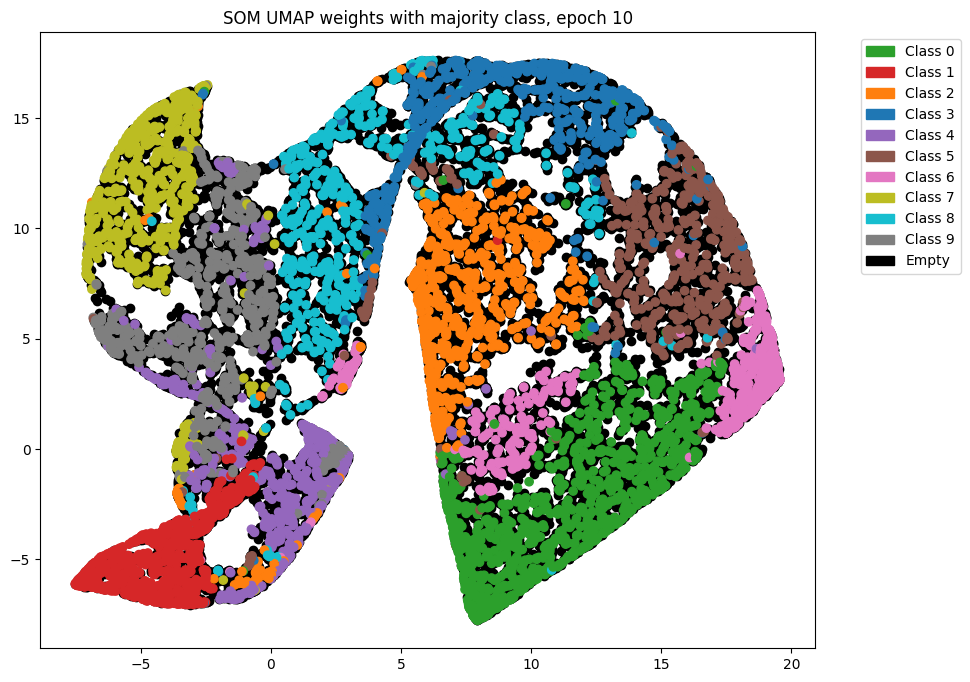

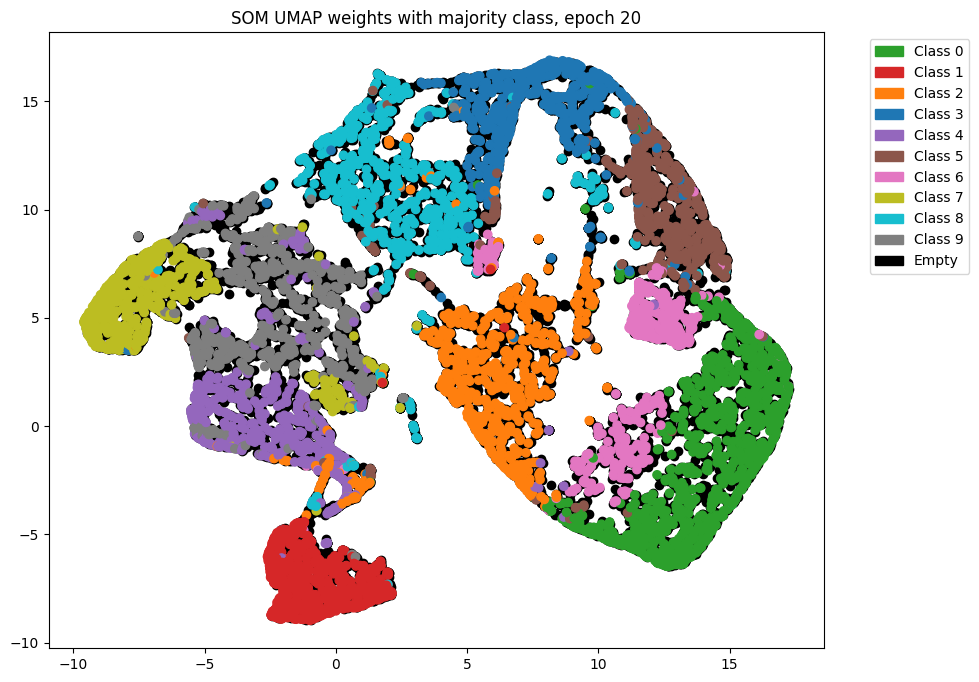

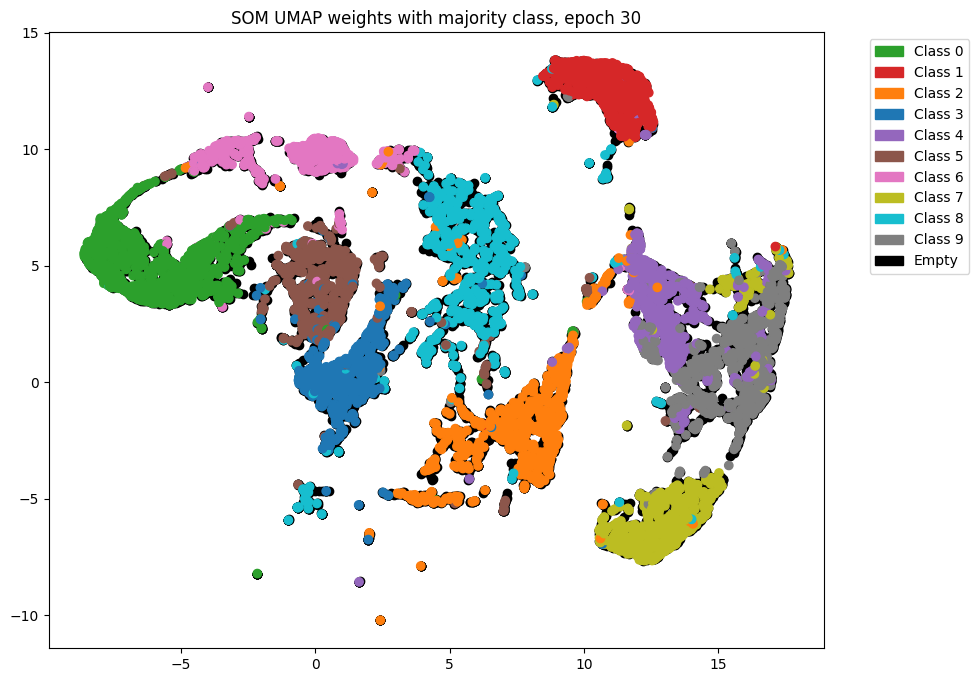

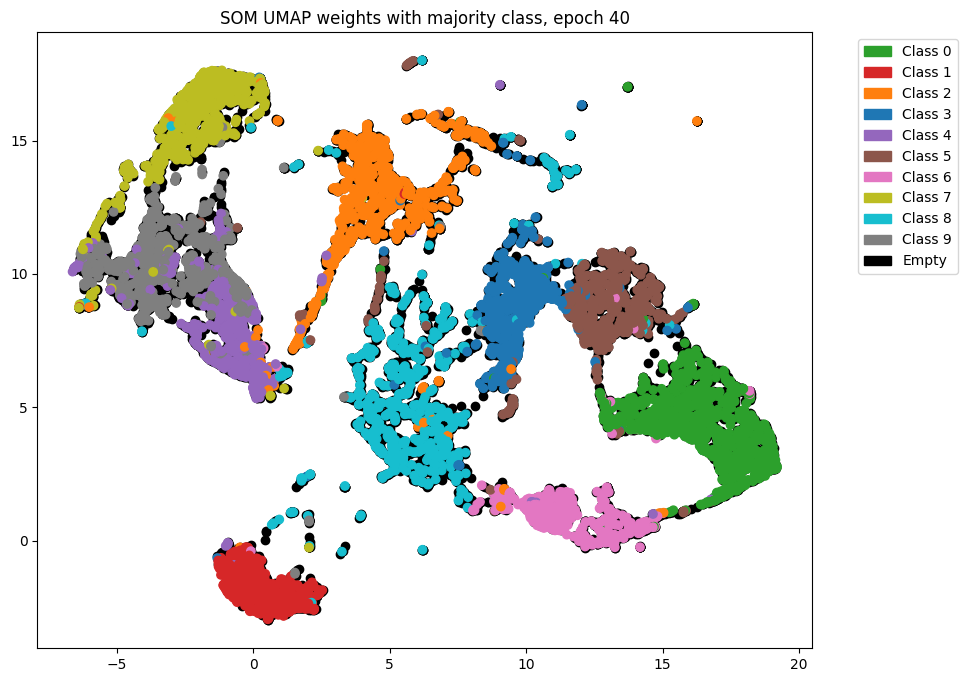

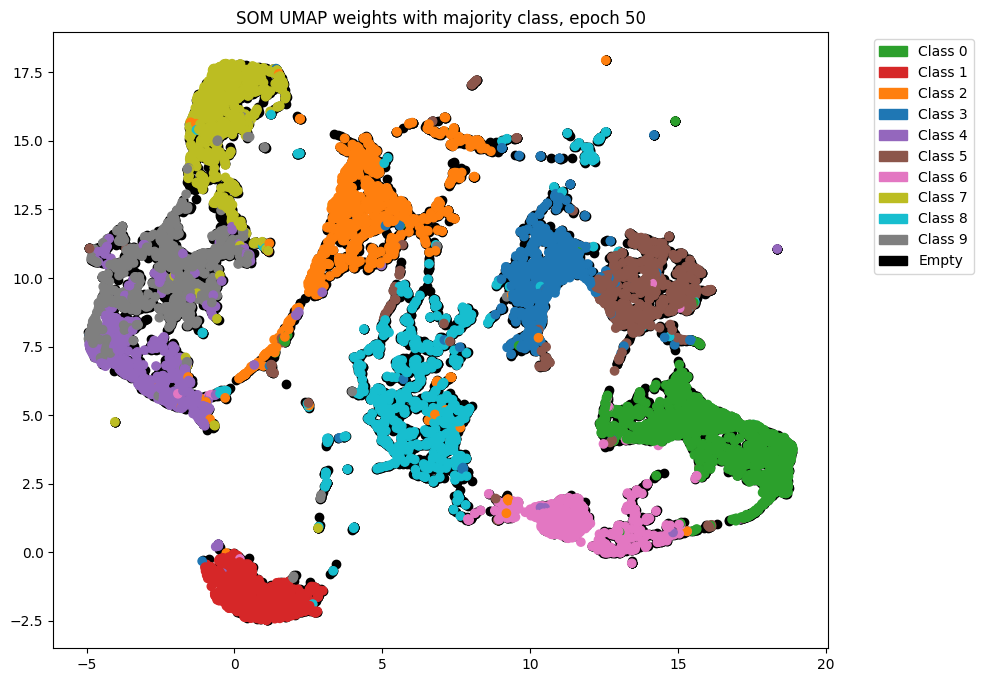

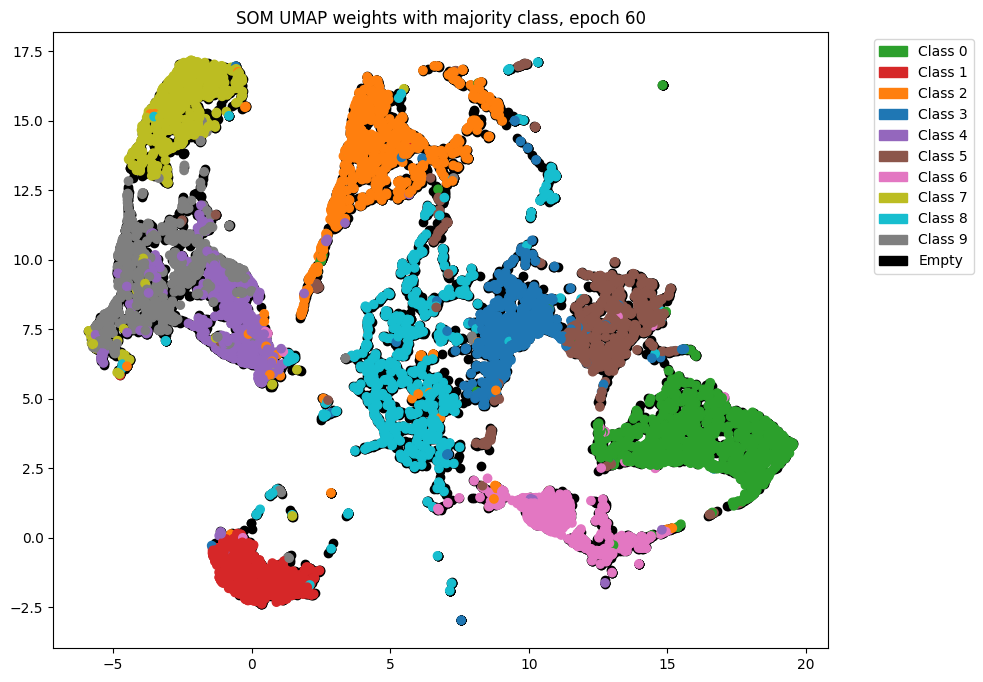

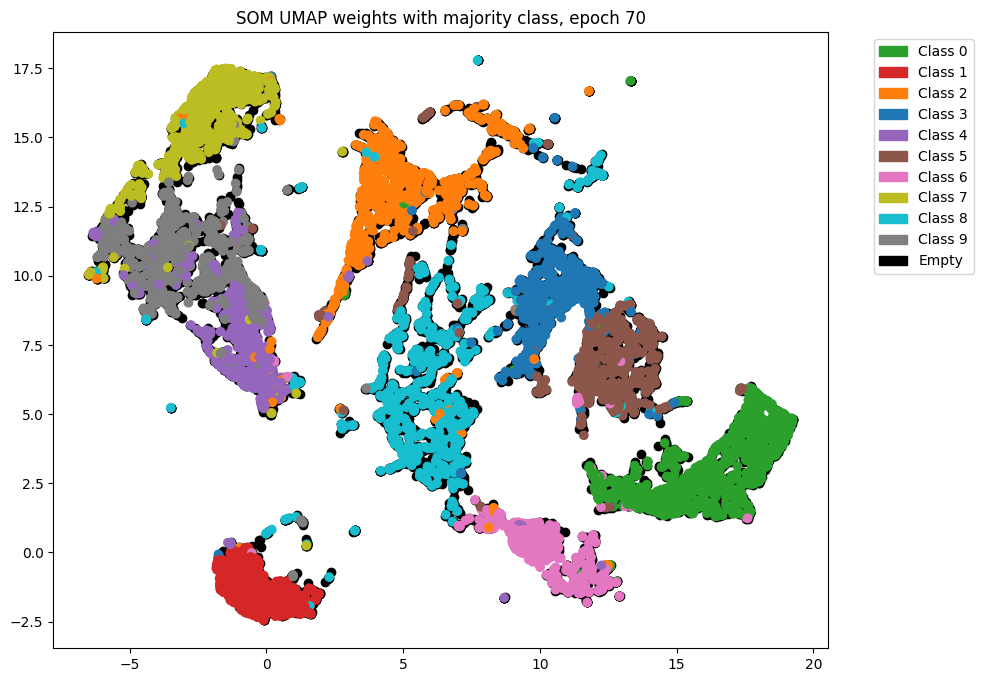

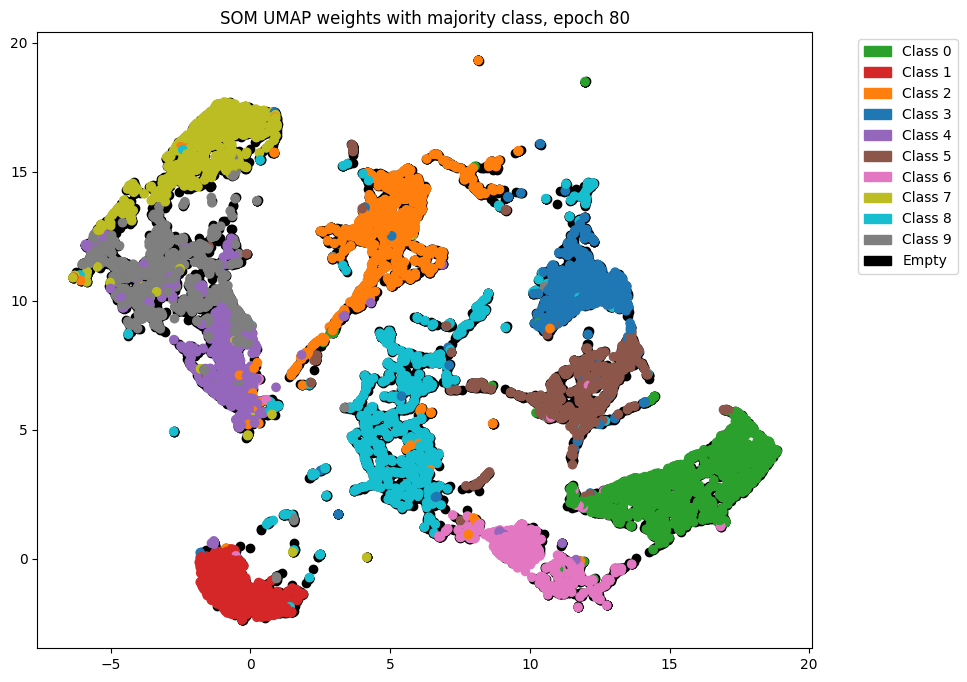

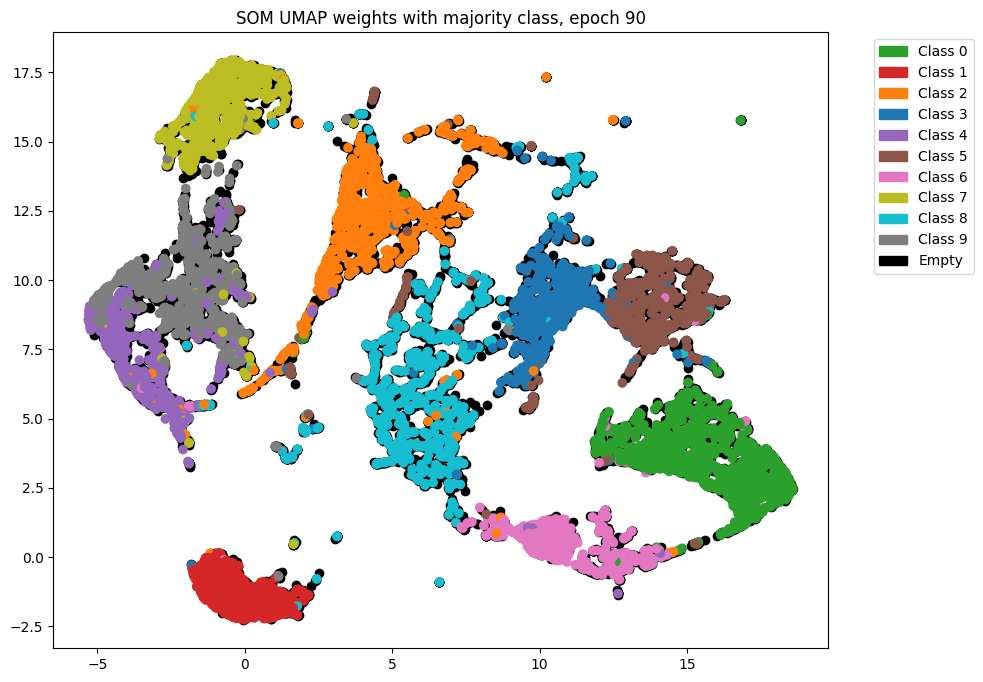

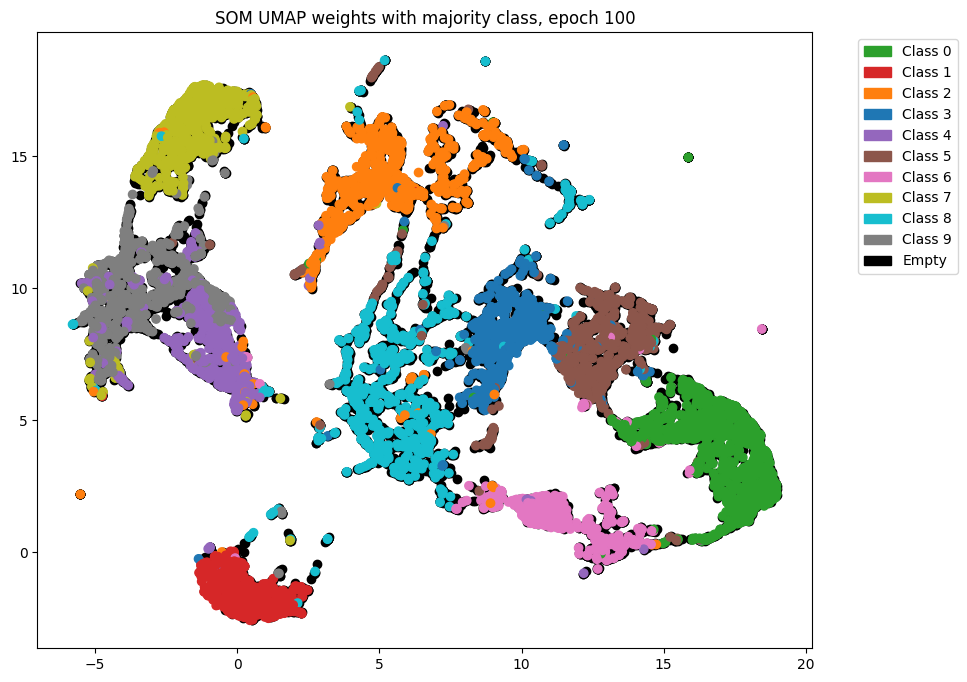

In [28]:
plot_umap_som_weights(snapshot_som_weights_finetuning, unique_labels)

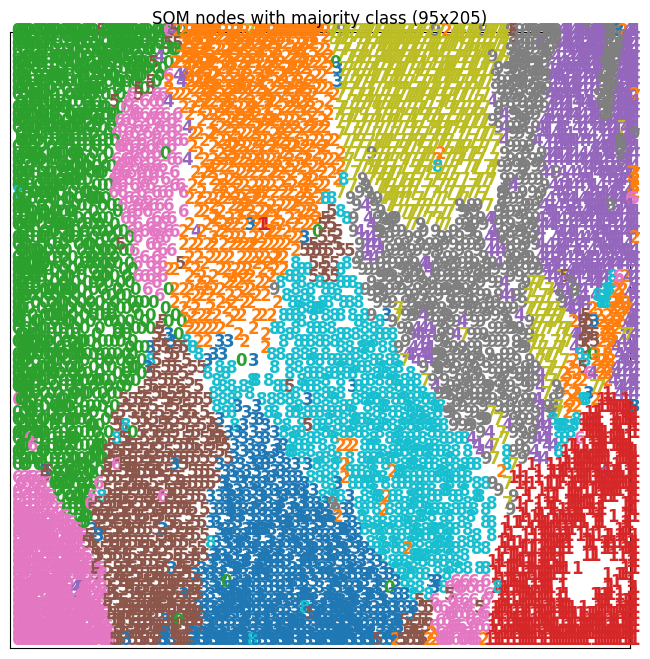

In [33]:
plot_som_mnist(snapshot_som_weights_finetuning, final_rows, final_cols)

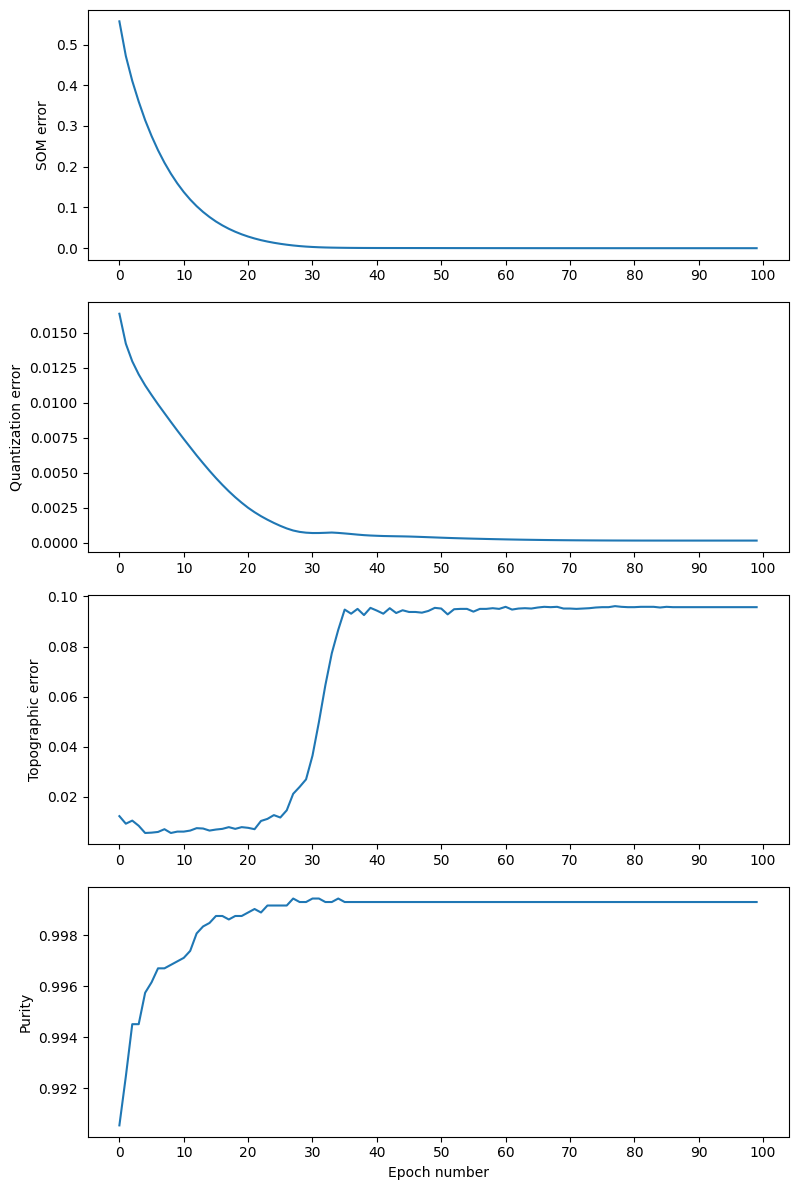

In [34]:
epochs_completed = len(history['QE'])
x = np.arange(epochs_completed)
xticks = np.arange(0, epochs_completed + 1, 10)

plt.figure(figsize=(8, 12))

plt.subplot(4,1,1)
plt.plot(x, history['som'])
plt.xticks(xticks)
plt.ylabel('SOM error')

plt.subplot(4,1,2)
plt.plot(x, history['QE'])
plt.xticks(xticks)
plt.ylabel('Quantization error')

plt.subplot(4,1,3)
plt.plot(x, history['TE'])
plt.xticks(xticks)
plt.ylabel('Topographic error')

plt.subplot(4,1,4)
plt.plot(x, history['purity'])
plt.xticks(xticks)
plt.ylabel('Purity')

plt.xlabel('Epoch number')
plt.tight_layout()
plt.show()